In [1]:
from ipywidgets import interact

import cartopy.crs as ccrs
import dask.dataframe as dd
from dask_ml.wrappers import ParallelPostFit
import joblib
from joblib import Parallel, delayed
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import shap
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, brier_score_loss, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from tqdm import tqdm

from lib.main import *
from lib.plot import *

from parameters import parameters

In [2]:
# Plate model name
plate_model_name = parameters["plate_model_name"]

# Timespan for analysis
temporal_resolution = parameters["temporal_resolution"]
time_min = parameters["timespan"]["min"]
time_max = parameters["timespan"]["max"]
time_steps = range(time_min, time_max + temporal_resolution, temporal_resolution)

columns_to_drop_target = parameters["columns_to_drop_target"]

plate_model_dir = parameters["plate_model_dir"]
inputs_dir = parameters["inputs_dir"]
outputs_dir = parameters["outputs_dir"]
ml_dir = parameters["ml_dir"]
prob_grids_dir = parameters["prob_grids_dir"]
entropy_grids_dir = parameters["entropy_grids_dir"]
vote_variance_grids_dir = parameters["vote_variance_grids_dir"]
prob_maps_dir = parameters["prob_maps_dir"]
entropy_maps_dir = parameters["entropy_maps_dir"]
vote_variance_maps_dir = parameters["vote_variance_maps_dir"]

Xy_train_new_filename = parameters["Xy_train_new_filename"]
Xy_rf_train_filename = parameters["Xy_rf_train_filename"]
Xy_rf_val_filename = parameters["Xy_rf_val_filename"]
Xy_rf_test_filename = parameters["Xy_rf_test_filename"]
Xy_pos_test_filename = parameters["Xy_pos_test_filename"]
gini_importances_filename = parameters["gini_importances_filename"]
permutation_importances_filename = parameters["permutation_importances_filename"]
shap_values_filename = parameters["shap_values_filename"]
features_shap_test_filename = parameters["features_shap_test_filename"]
target_data_filename = parameters["target_data_filename"]
target_prob_filename = parameters["target_prob_filename"]
deposit_recon_coords_all_filename = parameters["deposit_recon_coords_all_filename"]

model_rf_filename = parameters["model_rf_filename"]
model_rf_calibrated_filename = parameters["model_rf_calibrated_filename"]
robust_scaler_filename = parameters["robust_scaler_filename"]

ml_dir = os.path.join(outputs_dir, ml_dir)
prob_grids_dir = os.path.join(ml_dir, prob_grids_dir)
entropy_grids_dir = os.path.join(ml_dir, entropy_grids_dir)
vote_variance_grids_dir = os.path.join(ml_dir, vote_variance_grids_dir)
prob_maps_dir = os.path.join(ml_dir, prob_maps_dir)
entropy_maps_dir = os.path.join(ml_dir, entropy_maps_dir)
vote_variance_maps_dir = os.path.join(ml_dir, vote_variance_maps_dir)

Xy_train_new_filename = os.path.join(ml_dir, Xy_train_new_filename)
Xy_rf_train_filename = os.path.join(ml_dir, Xy_rf_train_filename)
Xy_rf_val_filename = os.path.join(ml_dir, Xy_rf_val_filename)
Xy_rf_test_filename = os.path.join(ml_dir, Xy_rf_test_filename)
Xy_pos_test_filename = os.path.join(ml_dir, Xy_pos_test_filename)
gini_importances_filename = os.path.join(ml_dir, gini_importances_filename)
permutation_importances_filename = os.path.join(ml_dir, permutation_importances_filename)
shap_values_filename = os.path.join(ml_dir, shap_values_filename)
features_shap_test_filename = os.path.join(ml_dir, features_shap_test_filename)
target_data_filename = os.path.join(outputs_dir, target_data_filename)
target_prob_filename = os.path.join(ml_dir, target_prob_filename)
deposit_recon_coords_all_filename = os.path.join(outputs_dir, deposit_recon_coords_all_filename)

model_rf_filename = os.path.join(ml_dir, model_rf_filename)
model_rf_calibrated_filename = os.path.join(ml_dir, model_rf_calibrated_filename)
robust_scaler_filename = os.path.join(ml_dir, robust_scaler_filename)

agegrid_dir = os.path.join(inputs_dir, "SeafloorAge")

nprocs = 8

### Random Forest

In [3]:
Xy_train_new = pd.read_csv(Xy_train_new_filename)
# Xy_train_new["label"] = Xy_train_new["label"].replace(2, 1)
Xy_train_new = Xy_train_new[Xy_train_new["label"] != 2]
Xy_train_new_ones = Xy_train_new[Xy_train_new["label"] == 1]
Xy_train_new_zeros = Xy_train_new[Xy_train_new["label"] == 0]
Xy_train_new_zeros_sampled = Xy_train_new_zeros.sample(n=len(Xy_train_new_ones), random_state=42)
Xy_train_new = pd.concat([Xy_train_new_ones, Xy_train_new_zeros_sampled])
Xy_train_new = Xy_train_new.sample(frac=1, random_state=42).reset_index(drop=True)

print("Number of positive samples:", len(Xy_train_new_ones))
print("Number of negative samples:", len(Xy_train_new_zeros_sampled))

features_rf = Xy_train_new.copy()
features_rf = features_rf.drop("label", axis=1)
labels_rf = Xy_train_new["label"]

if os.path.isfile(model_rf_calibrated_filename):
    model_rf = joblib.load(model_rf_filename)
    model_rf_calibrated = joblib.load(model_rf_calibrated_filename)
    Xy_rf_train = pd.read_csv(Xy_rf_train_filename)
    Xy_rf_val = pd.read_csv(Xy_rf_val_filename)
    Xy_rf_test = pd.read_csv(Xy_rf_test_filename)
else:
    # Random Forest model structure
    rf = RandomForestClassifier(n_jobs=nprocs, random_state=42)

    n_fold = 10

    # Split into train (60%), validation (20%), and test (20%)
    X_rf_train_temp, X_rf_test, y_rf_train_temp, y_rf_test = train_test_split(features_rf, labels_rf, test_size=0.2, random_state=42)
    # Further split training data to create a validation set
    X_rf_train, X_rf_val, y_rf_train, y_rf_val = train_test_split(X_rf_train_temp, y_rf_train_temp, test_size=0.25, random_state=42)
    
    Xy_rf_train = np.hstack((X_rf_train, y_rf_train.values.reshape(-1, 1)))
    Xy_rf_train = pd.DataFrame(Xy_rf_train, columns=Xy_train_new.columns)
    Xy_rf_train.to_csv(Xy_rf_train_filename, index=False)
    
    Xy_rf_val = np.hstack((X_rf_val, y_rf_val.values.reshape(-1, 1)))
    Xy_rf_val = pd.DataFrame(Xy_rf_val, columns=Xy_train_new.columns)
    Xy_rf_val.to_csv(Xy_rf_val_filename, index=False)
    
    Xy_rf_test = np.hstack((X_rf_test, y_rf_test.values.reshape(-1, 1)))
    Xy_rf_test = pd.DataFrame(Xy_rf_test, columns=Xy_train_new.columns)
    Xy_rf_test.to_csv(Xy_rf_test_filename, index=False)

    weights_rf_train = Xy_rf_train["weight"]
    X_rf_train = Xy_rf_train[[col for col in Xy_rf_train.columns if col not in ["weight", "label"]]]
    
    weights_rf_val = Xy_rf_val["weight"]
    X_rf_val = Xy_rf_val[[col for col in Xy_rf_val.columns if col not in ["weight", "label"]]]
    
    weights_rf_test = Xy_rf_test["weight"]
    X_rf_test = Xy_rf_test[[col for col in Xy_rf_test.columns if col not in ["weight", "label"]]]

    # Bayesian search for hyperparameters
    search_space = {
    "bootstrap": Categorical([True, False]),
    "max_depth": Integer(5, 20),
    "max_features": Categorical([None, "sqrt","log2"]), 
    "min_samples_leaf": Integer(2, 20),
    "min_samples_split": Integer(2, 30),
    "n_estimators": Integer(10, 200)
    }

    rf_bayes_search = BayesSearchCV(
        rf,
        search_space,
        n_iter=50, # specify how many iterations
        scoring="f1",
        n_jobs=nprocs,
        cv=n_fold,
        verbose=1,
        random_state=42
    )
    
    # Fit the model using training data
    rf_bayes_search.fit(X_rf_train, y_rf_train, sample_weight=weights_rf_train)
    
    # Extract the optimization results
    optimization_results = rf_bayes_search.cv_results_["mean_test_score"]
    
    model_rf = rf_bayes_search.best_estimator_
    model_rf_f1 = rf_bayes_search.best_score_    
    print("The highest F1-score during cross validation:", model_rf_f1)
    
    # Evaluate uncalibrated model on validation set
    uncalibrated_probs = model_rf.predict_proba(X_rf_val)[:, 1]
    uncalibrated_brier = brier_score_loss(y_rf_val, uncalibrated_probs)
    print("Uncalibrated Brier Score (validation set):", uncalibrated_brier)

    # Calibrate using the validation data
    model_rf_calibrated = CalibratedClassifierCV(model_rf, method='isotonic', cv='prefit')
    model_rf_calibrated.fit(X_rf_test, y_rf_test, sample_weight=weights_rf_val)
    
    # Save the original and calibrated model
    joblib.dump(model_rf, model_rf_filename)
    joblib.dump(model_rf_calibrated, model_rf_calibrated_filename)
    
    # Evaluate both models on the test set
    uncal_test_probs = model_rf.predict_proba(X_rf_test)[:, 1]
    cal_test_probs = model_rf_calibrated.predict_proba(X_rf_test)[:, 1]
    
    uncal_brier = brier_score_loss(y_rf_test, uncal_test_probs)
    cal_brier = brier_score_loss(y_rf_test, cal_test_probs)
    
    print("Test Set Results:")
    print("Uncalibrated Brier Score:", uncal_brier)
    print("Calibrated Brier Score:", cal_brier)
    print(f"Improvement: {(uncal_brier - cal_brier) / uncal_brier * 100:.2f}%")

    # Calculate calibration curves
    uncal_fraction, uncal_predicted = calibration_curve(y_rf_test, uncal_test_probs, n_bins=20)
    cal_fraction, cal_predicted = calibration_curve(y_rf_test, cal_test_probs, n_bins=20)
    
    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns
    
    # Plot 1: Bayesian Optimization Progress
    axes[0].plot(range(1, len(optimization_results) + 1),
                optimization_results, marker="o", color="black", markerfacecolor="red")
    axes[0].set_xlim(0, len(optimization_results) + 1)
    axes[0].set_xlabel("Bayesian Optimization Iteration")
    axes[0].set_ylabel("Mean Test F1 Score")
    axes[0].set_title("Bayesian Optimization Progress")
    axes[0].grid(True, linestyle=":")
    
    # Plot 2: Reliability Curve (Uncalibrated)
    axes[1].plot(uncal_predicted, uncal_fraction, marker='o', 
                label=f'Uncalibrated (Brier: {uncal_brier:.4f})')
    axes[1].plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
    axes[1].set_xlabel("Mean predicted probability")
    axes[1].set_ylabel("Fraction of positives")
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_title("Uncalibrated Reliability Curve")
    
    # Plot 3: Reliability Curve (Calibrated)
    axes[2].plot(cal_predicted, cal_fraction, marker='o', 
                label=f'Calibrated (Brier: {cal_brier:.4f})')
    axes[2].plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
    axes[2].set_xlabel("Mean predicted probability")
    axes[2].set_ylabel("Fraction of positives")
    axes[2].legend()
    axes[2].grid(True)
    axes[2].set_title("Calibrated Reliability Curve")
    
    plt.tight_layout()
    plt.show()

Number of positive samples: 971
Number of negative samples: 971


In [4]:
features_rf_test = Xy_rf_test.copy()
features_rf_test = features_rf_test.drop(["weight", "label"], axis=1)
labels_rf_test = Xy_rf_test["label"]
weights_rf_test = Xy_rf_test["weight"]

labels_pred = model_rf_calibrated.predict(features_rf_test)

rf_cmatrix = confusion_matrix(labels_rf_test, labels_pred)
rf_acc = accuracy_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)
rf_pre = precision_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)
rf_rec = recall_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)
rf_f1 = f1_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)

print("Confusion matrix:\n", rf_cmatrix)
print("Accuracy:", rf_acc)
print("Precision:", rf_pre)
print("Recall:", rf_rec)
print("F1-Score:", rf_f1)

Confusion matrix:
 [[169  21]
 [ 23 176]]
Accuracy: 0.8522012578616353
Precision: 0.9467005076142132
Recall: 0.8363228699551569
F1-Score: 0.888095238095238


In [5]:
Xy_pos_test = pd.read_csv(Xy_pos_test_filename)
X_pos_test = Xy_pos_test[[col for col in Xy_pos_test.columns if col not in ["weight", "label"]]]
y_pos_test = Xy_pos_test["label"]
weights_pos_test = Xy_pos_test["weight"]
X_pos_pred = model_rf_calibrated.predict(X_pos_test)
X_pos_pred_acc = accuracy_score(y_pos_test, X_pos_pred, sample_weight=weights_pos_test)
print("Accuracy:", X_pos_pred_acc)

Accuracy: 0.859375


### ROC Plot

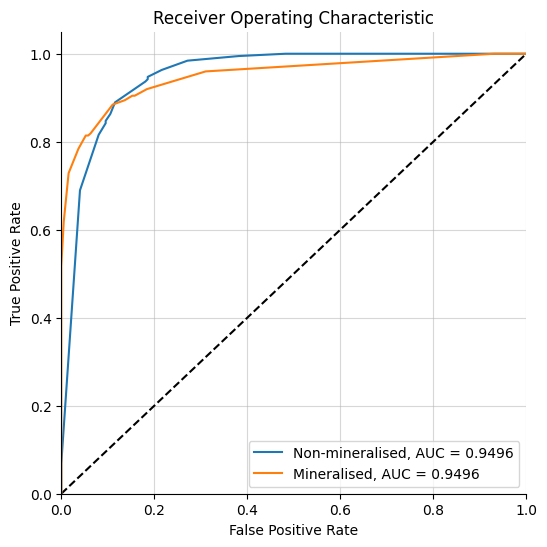

ROC AUC score: 0.9496032795556731


In [6]:
labels_prob = model_rf_calibrated.predict_proba(features_rf_test)
labels_name = ["Non-mineralised", "Mineralised"]
roc_plot(labels_rf_test, labels_prob, 2, labels_name)

### Feature Importance (Gini Importance)

Feature importance is a metric used by tree-based models like Random Forests to estimate the relative contribution of each feature to the model's predictions. It is computed by averaging the total reduction in Gini impurity (a measure of node impurity) brought by each feature across all trees in the forest. Features that more frequently and more significantly reduce impurity are considered more important. This helps in understanding which variables have the most influence in the model's decision-making process.

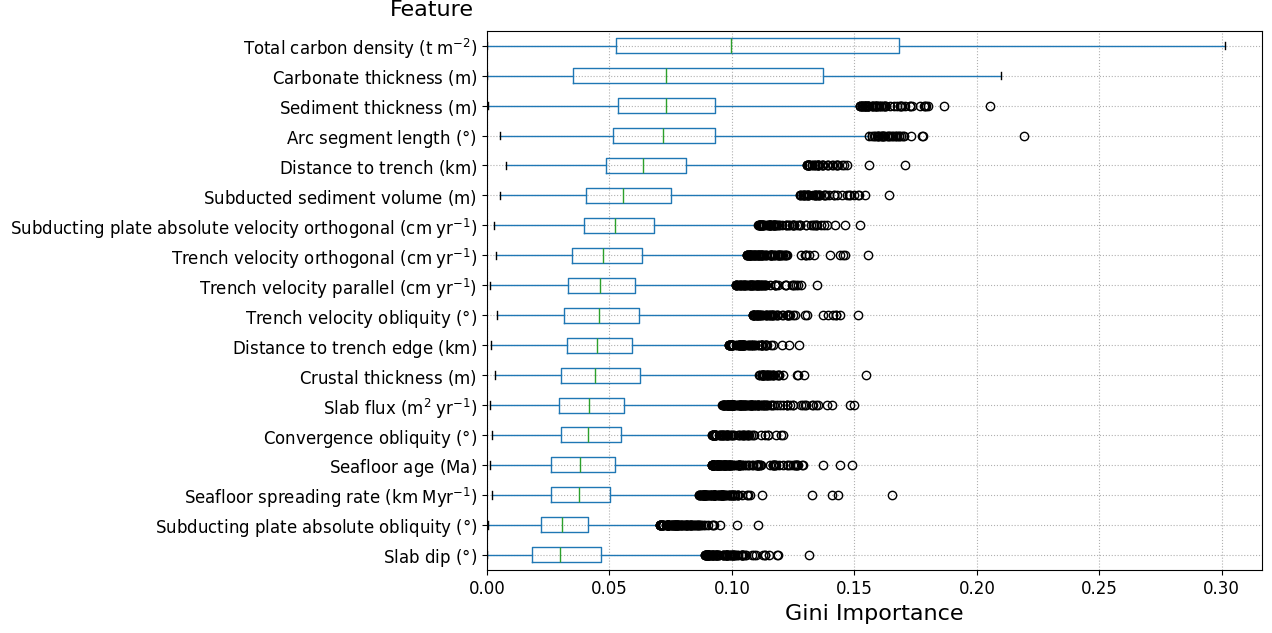

In [7]:
if os.path.isfile(gini_importances_filename):
    gini_importances = pd.read_csv(gini_importances_filename)
else:    
    # Setup
    n_splits = 5
    n_repeats = 10
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42,
    )
    feature_names = features_rf_test.columns
    gini_importances_all = []

    # Cross-validate with the best estimator
    for idx, _ in cv.split(features_rf, labels_rf):
        features_fold = features_rf.iloc[idx]
        weights_fold = features_fold["weight"]
        features_fold = features_fold.drop("weight", axis=1)
        labels_fold = labels_rf.iloc[idx]

        # Clone and fit
        clf = clone(model_rf_calibrated.estimator)
        clf.fit(features_fold, labels_fold, sample_weight=weights_fold)

        # Extract per-tree importances
        tree_importances = pd.DataFrame(
            [tree.feature_importances_ for tree in clf.estimators_],
            columns=feature_names
        )
        gini_importances_all.append(tree_importances)

    # Combine all results into one DataFrame
    gini_importances = pd.concat(gini_importances_all, ignore_index=True)

    # Sort columns by median importance
    gini_importances = gini_importances[gini_importances.median().sort_values(ascending=False).index]

    # Save to CSV
    gini_importances.to_csv(gini_importances_filename, index=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Reverse column order so the most important is on top
gini_importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)

# Customize plot
ax.grid(linestyle="dotted")
ax.set_xlim(0)
ax.set_xlabel("Gini Importance", fontsize=16)
ax.set_ylabel("Feature", rotation=0, ha="right", fontsize=16)
ax.yaxis.set_label_coords(-0.017, 1.02)

# Format y-tick labels
ax.set_yticks(
    ax.get_yticks(),
    [format_feature_name(label.get_text()) for label in ax.get_yticklabels()]
)

# Style tick labels
ax.tick_params(labelsize=12)

plt.show()

### Permutation Importance

Permutation importance is a model-agnostic technique used to evaluate the impact of each feature on a model's predictive performance. It works by randomly shuffling the values of a single feature in the test data and measuring how much the model's performance decreases. If permuting a feature's values significantly degrades the model's score (e.g., F1), it indicates that the feature is important. This method provides a more direct assessment of feature relevance than internal metrics like Gini importance, especially in the presence of feature interactions or correlations.

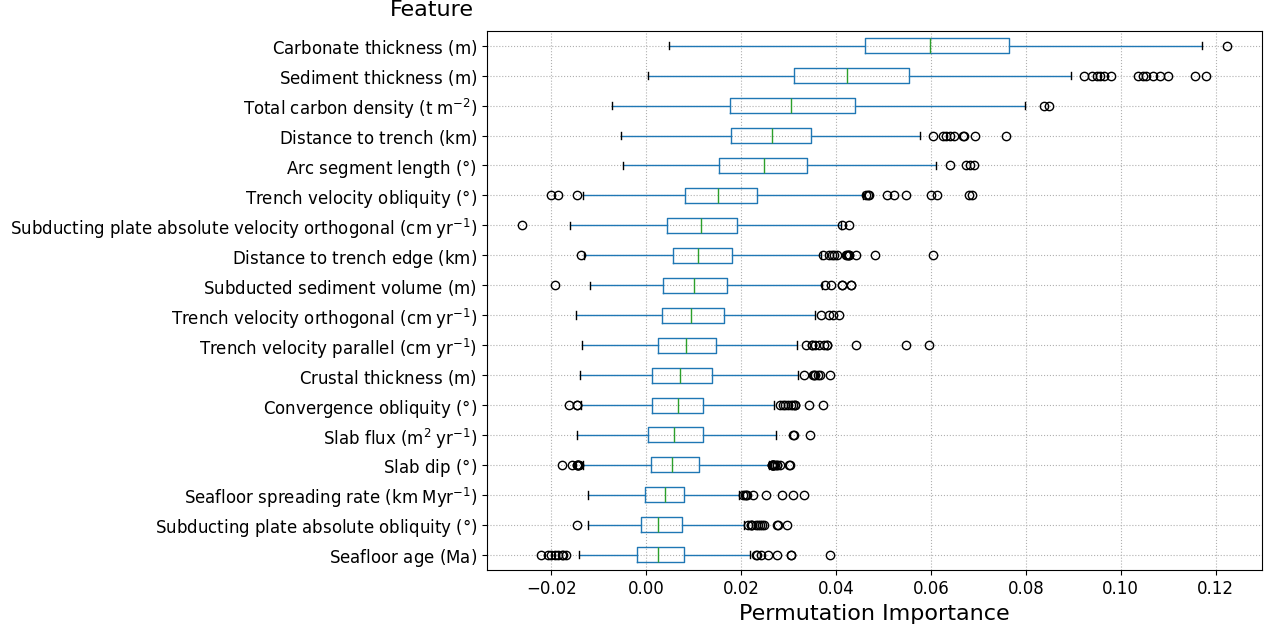

In [8]:
if os.path.isfile(permutation_importances_filename):
    permutation_importances = pd.read_csv(permutation_importances_filename)
else:
    # Setup
    n_splits = 5
    n_repeats = 10
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42,
    )
    feature_names = features_rf_test.columns
    permutation_importances_all = []

    # Cross-validate with the best estimator
    for train_idx, test_idx in cv.split(features_rf, labels_rf):
        features_train = features_rf.iloc[train_idx]
        weights_train = features_train["weight"]
        features_train = features_train.drop("weight", axis=1)
        labels_train = labels_rf.iloc[train_idx]
        features_test = features_rf.iloc[test_idx]
        weights_test = features_test["weight"]
        features_test = features_test.drop("weight", axis=1)
        labels_test = labels_rf.iloc[test_idx]

        # Clone and fit
        clf = clone(model_rf_calibrated.estimator)
        clf.fit(features_train, labels_train, sample_weight=weights_train)

        result = permutation_importance(clf, features_test, labels_test, sample_weight=weights_test, scoring="f1", n_repeats=10, random_state=42, n_jobs=nprocs)
        result_df = pd.DataFrame(result.importances.T, columns=feature_names)
        permutation_importances_all.append(result_df)

    # Combine all results into one DataFrame
    permutation_importances = pd.concat(permutation_importances_all, ignore_index=True)

    # Sort columns by median importance
    permutation_importances = permutation_importances[permutation_importances.median().sort_values(ascending=False).index]

    # Save to CSV
    permutation_importances.to_csv(permutation_importances_filename, index=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Reverse column order so the most important is on top
permutation_importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)

# Customize plot
ax.grid(linestyle="dotted")
ax.set_xlabel("Permutation Importance", fontsize=16)
ax.set_ylabel("Feature", rotation=0, ha="right", fontsize=16)
ax.yaxis.set_label_coords(-0.017, 1.02)

# Format y-tick labels
ax.set_yticks(
    ax.get_yticks(),
    [format_feature_name(label.get_text()) for label in ax.get_yticklabels()]
)

# Style tick labels
ax.tick_params(labelsize=12)

plt.show()

### Partial Dependence and Individual Conditional Expectation

In [19]:
features_rf_train = Xy_rf_train.copy()
labels_rf_train = features_rf_train["label"]
weights_rf_train = features_rf_train["weight"]
features_rf_train = features_rf_train.drop(["weight", "label"], axis=1)
feature_names = features_rf_train.columns

robust_scaler = joblib.load(robust_scaler_filename)
features_rf_train_original_values = features_rf_train * robust_scaler.scale_ + robust_scaler.center_

@interact
def show_pdp_ice(feature=feature_names):
    plt.figure(figsize=(8, 6))

    # Compute partial dependence and ICE
    pd_result = partial_dependence(
        estimator=model_rf_calibrated.estimator,
        X=features_rf_train,
        features=[feature],
        sample_weight=weights_rf_train,
        kind='both',
        method='brute',
        grid_resolution=100,
        percentiles=(0.05, 0.95),
    )

    averaged = pd_result.average[0]
    individual = pd_result.individual[0]
    grid_values = pd_result.grid_values[0]

    # Plot ICE with label-based coloring
    for i, ice_line in enumerate(individual):
        label = labels_rf_train.iloc[i]
        color = 'LightSalmon' if label == 1 else 'DarkSeaGreen'
        plt.plot(grid_values, ice_line, color=color, alpha=0.3, linewidth=0.7)

    # Plot PDP
    plt.plot(grid_values, averaged, color='black', linewidth=2, linestyle='--')

    # Main x-axis ticks (outward, labeled, default spacing)
    plt.tick_params(axis='x', direction='out', length=6)

    # Add secondary inward ticks for percentiles (unlabeled)
    percentiles = np.linspace(5, 95, 11)
    percentile_values = np.percentile(features_rf_train_original_values[feature], percentiles)
    feature_min = features_rf_train_original_values[feature].quantile(0.05)
    feature_max = features_rf_train_original_values[feature].quantile(0.95)
    x_min = grid_values.min()
    x_max = grid_values.max()
    ax = plt.gca()
    plt.xlim(x_min, x_max)
    inward_tick_positions = (percentile_values - feature_min) / (feature_max - feature_min) * (x_max - x_min) + x_min

    for tick in inward_tick_positions:
        plt.axvline(x=tick, ymin=0, ymax=0.03, color='black', linewidth=1)

    x_ticks = ax.get_xticks()
    mask = (x_ticks >= x_min) & (x_ticks <= x_max)
    x_ticks = x_ticks[mask]
    ax.set_xticks(x_ticks)
    
    original_tick_values = feature_min + (x_ticks - x_min) * (feature_max - feature_min) / (x_max - x_min)
    original_tick_labels = [f"{val:.4f}" for val in original_tick_values]
    ax.set_xticklabels(original_tick_labels)
        
    # Axis labeling and title
    plt.xlabel(format_feature_name(feature))
    plt.ylabel("Partial dependence")
    plt.title(f"Partial Dependence and ICE for '{format_feature_name(feature)}'")    
    # Add legend
    pos_line = Line2D([], [], color='LightSalmon', alpha=0.6, label='Positive')
    neg_line = Line2D([], [], color='DarkSeaGreen', alpha=0.6, label='Negative')
    avg_line = Line2D([], [], color='black', linestyle='--', linewidth=2, label='Average')
    plt.legend(handles=[pos_line, neg_line, avg_line], loc='upper left')
    
    plt.show()


interactive(children=(Dropdown(description='feature', options=('arc_segment_length (degrees)', 'carbonate_thic…

### SHAP Values

SHAP (SHapley Additive exPlanations) values provide a unified measure of feature importance by quantifying how much each feature contributes to a specific prediction. Based on cooperative game theory, SHAP values fairly distribute the difference between a model's prediction and the average prediction among all input features. Unlike methods that only give global importance, SHAP values offer both global and local interpretability, showing not just which features are important, but also how they influence individual predictions—positively or negatively.

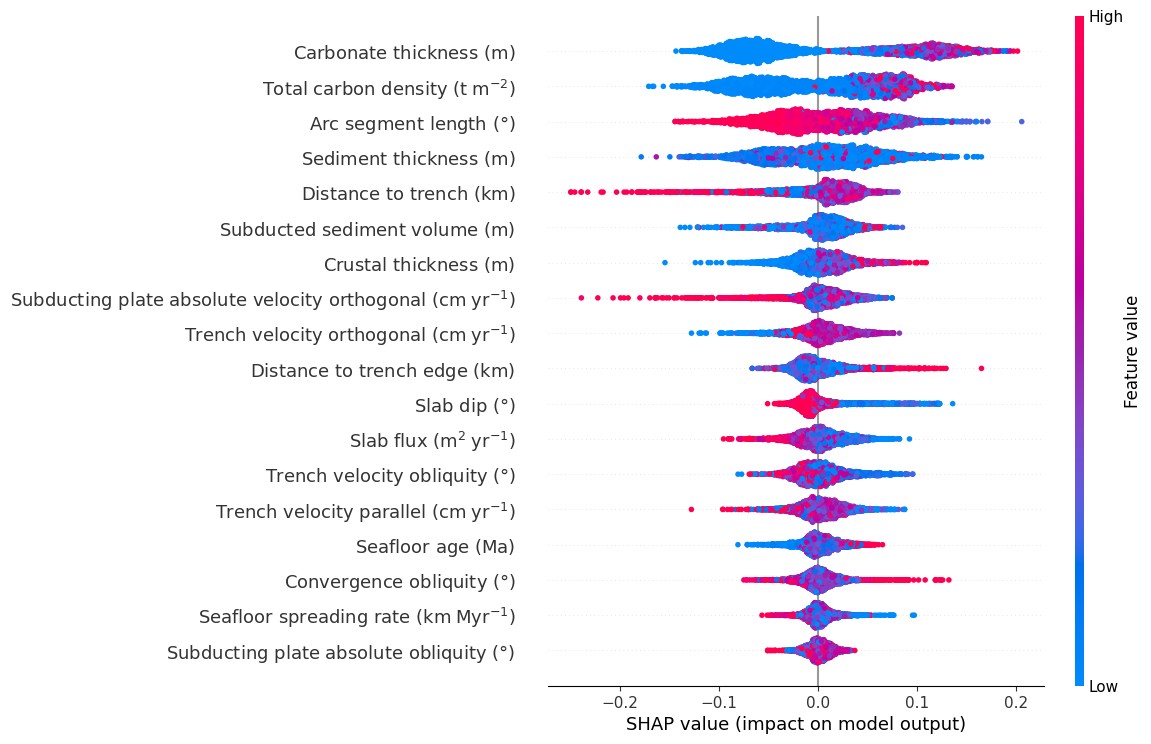

In [10]:
if os.path.isfile(shap_values_filename):
    shap_values = pd.read_csv(shap_values_filename)
    shap_values_array = shap_values.values
    features_shap_test = pd.read_csv(features_shap_test_filename)
    feature_names = features_rf_test.columns
else:
    # Setup
    n_splits = 5
    n_repeats = 2
    total_folds = n_splits * n_repeats
    
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42,
    )
    
    test_idx_all = []
    shap_values_all = []

    # Cross-validate with the best estimator
    for train_idx, test_idx in tqdm(cv.split(features_rf, labels_rf), total=total_folds, desc="Computing SHAP"):
        features_train = features_rf.iloc[train_idx]
        weights_train = features_train["weight"]
        features_train = features_train.drop("weight", axis=1)
        labels_train = labels_rf.iloc[train_idx]
        
        features_test = features_rf.iloc[test_idx]
        weights_test = features_test["weight"]
        features_test = features_test.drop("weight", axis=1)
        labels_test = labels_rf.iloc[test_idx]
        test_idx_all.extend(test_idx)

        # Clone and fit
        clf = clone(model_rf)
        clf.fit(features_train, labels_train, sample_weight=weights_train)

        # Compute SHAP values on the test set
        explainer = shap.TreeExplainer(clf, features_train)  # Use training data as background
        result = explainer(features_test, check_additivity=False)
        shap_values_all.append(result)
    
    shap_values_array = np.vstack([sv.values[:, :, 1] for sv in shap_values_all])
    feature_names = features_rf_test.columns
    shap_values = pd.DataFrame(shap_values_array, columns=feature_names)
    shap_values.to_csv(shap_values_filename, index=False)
    features_shap_test = features_rf.iloc[test_idx_all].drop("weight", axis=1)
    features_shap_test.to_csv(features_shap_test_filename, index=False)

feature_names = [format_feature_name(name) for name in feature_names]

explanation = shap.Explanation(
    values=shap_values_array,
    data=features_shap_test.values,
    feature_names=feature_names
)

shap.plots.beeswarm(explanation, max_display=20)

### Calculate Probability, Entropy, and Vote Variance

In [11]:
if os.path.isfile(target_prob_filename):
    print(f"Probabilities have already been calculated and saved in {target_prob_filename}")
else:
    columns = [
        "lon",
        "lat",
        "present_lon",
        "present_lat",
        "age (Ma)",
    ]

    target_data_dd = dd.read_csv(target_data_filename)
    target_data_out = target_data_dd[columns].compute()
    
    selected_features = model_rf_calibrated.feature_names_in_
    
    target_data = pd.read_csv(target_data_filename)
    target_data_scaled = target_data[selected_features]
    target_data_scaled = robust_scaler.transform(target_data_scaled)
    target_data_scaled = pd.DataFrame(target_data_scaled, columns=selected_features)
    target_data_scaled[columns_to_drop_target] = target_data[columns_to_drop_target]
    
    model_rf_parallel = ParallelPostFit(model_rf_calibrated)

    target_features = target_data_scaled[selected_features]
    probs = model_rf_parallel.predict_proba(target_features)[:, 1].ravel()
    target_prob = target_data_out.copy()
    target_prob["probability"] = probs
    entropies = calculate_entropy(probs)
    target_prob["entropy"] = entropies
    vote_variances = calculate_tree_vote_variance(model_rf_calibrated.estimator, target_features.values)
    target_prob["vote_variance"] = vote_variances
    
    del probs
    target_prob.to_csv(target_prob_filename, index=False)
    del target_prob

if os.path.exists(prob_grids_dir):
    print(f"Probability grids are located in {prob_grids_dir}")
else:
    os.makedirs(prob_grids_dir, exist_ok=True)
    os.makedirs(entropy_grids_dir, exist_ok=True)
    os.makedirs(vote_variance_grids_dir, exist_ok=True)

    create_grids(
        data=target_prob_filename,
        output_dir=prob_grids_dir,
        extent=(-180, 180, -90, 90),
        threads=nprocs,
        verbose=True,
        column="probability",
        filename_format="probability_grid_{}Ma.nc",        
    )
    
    create_grids(
        data=target_prob_filename,
        output_dir=entropy_grids_dir,
        extent=(-180, 180, -90, 90),
        threads=nprocs,
        verbose=True,
        column="entropy",
        filename_format="entropy_grid_{}Ma.nc",        
    )
    
    create_grids(
        data=target_prob_filename,
        output_dir=vote_variance_grids_dir,
        extent=(-180, 180, -90, 90),
        threads=nprocs,
        verbose=True,
        column="vote_variance",
        filename_format="vote_variance_grid_{}Ma.nc",        
    )

Probabilities have already been calculated and saved in outputs\ml\target_prob.csv
Probability grids are located in outputs\ml\prob_grids


### Probability Maps

In [12]:
plate_model, _tf = get_plate_reconstruction(
    model_name=plate_model_name,
    model_dir=plate_model_dir,
    filter_topologies=True,
)

gplot = get_plot_topologies(
    model_name=plate_model_name,
    model_dir=plate_model_dir,
    plate_reconstruction=plate_model,
    filter_topologies=True,
)

projection = ccrs.Mollweide(central_longitude=60)
central_meridian = 0

In [13]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            prob_grids_dir,
            f"probability_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="probability",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        positives=deposit_recon_coords_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [14]:
if os.path.exists(prob_maps_dir):
    print(f"Probability maps are located in {prob_maps_dir}")
else:
    os.makedirs(prob_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=nprocs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // nprocs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(prob_maps_dir, f"probability_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot)(
                gplot=gplot,
                grid=os.path.join(
                    prob_grids_dir,
                    f"probability_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="probability",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_recon_coords_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "probability_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Probability maps are located in outputs\ml\prob_maps


### Entropy Maps

In [15]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            entropy_grids_dir,
            f"entropy_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="entropy",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        positives=deposit_recon_coords_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [16]:
if os.path.exists(entropy_maps_dir):
    print(f"Entropy maps are located in {entropy_maps_dir}")
else:
    os.makedirs(entropy_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=nprocs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // nprocs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(entropy_maps_dir, f"entropy_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot)(
                gplot=gplot,
                grid=os.path.join(
                    entropy_grids_dir,
                    f"entropy_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="entropy",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_recon_coords_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "entropy_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Entropy maps are located in outputs\ml\entropy_maps


### Vote Variance Maps

In [17]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        grid=os.path.join(
            vote_variance_grids_dir,
            f"vote_variance_grid_{time:0.0f}Ma.nc",
        ),
        grid_type="vote variance",
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        positives=deposit_recon_coords_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [18]:
if os.path.exists(vote_variance_maps_dir):
    print(f"Vote variance maps are located in {vote_variance_maps_dir}")
else:
    os.makedirs(vote_variance_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=nprocs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // nprocs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(vote_variance_maps_dir, f"vote_variance_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot)(
                gplot=gplot,
                grid=os.path.join(
                    vote_variance_grids_dir,
                    f"vote_variance_grid_{t:0.0f}Ma.nc",
                ),
                grid_type="vote variance",
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_recon_coords_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "vote_variance_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Vote variance maps are located in outputs\ml\vote_variance_maps
